In [1]:
import math
import re
import numpy as np
import pandas as pd
import QuantLib as ql

### Using quantlib for dates

### Market data and basic setup

In [2]:
trade_date = ql.Date(5, 11, 2025)
calendar = ql.TARGET()
spot_date = calendar.advance(trade_date, 2, ql.Days)

bdc = ql.ModifiedFollowing
dc_deposit = ql.Actual360()
dc_swap = ql.Thirty360(ql.Thirty360.BondBasis)
dc_curve = ql.Actual365Fixed()   # for TTM and zero-rate reporting

raw = pd.read_excel("curve_quotes.xlsx").copy()
raw["Type"] = raw["Type"].str.upper().str.strip()
raw["QuoteDec"] = raw["Quote"] / 100.0

FileNotFoundError: [Errno 2] No such file or directory: 'curve_quotes.xlsx'

### Helper functions

In [ ]:
def extract_tenor(instr):
    s = str(instr).upper().strip()

    if "O/N" in s or re.search(r"\bON\b", s):
        return "O/N"

    m = re.search(r"(\d+)\s*([WMY])\b", s)
    if m:
        return f"{m.group(1)}{m.group(2)}"

    raise ValueError(f"Could not extract tenor from instrument: {instr}")


def tenor_years(tenor):
    if tenor == "O/N":
        return 1 / 365.0
    n = int(re.findall(r"\d+", tenor)[0])
    u = tenor[-1]
    if u == "W":
        return n / 52.0
    if u == "M":
        return n / 12.0
    if u == "Y":
        return float(n)
    raise ValueError(f"Unsupported tenor: {tenor}")


def ql_maturity_from_tenor(start_date, tenor):
    if tenor == "O/N":
        return calendar.advance(start_date, 1, ql.Days)
    return calendar.advance(start_date, ql.Period(tenor), bdc)


def start_date_from_tenor(tenor):
    return spot_date


def ttm(maturity):
    return dc_curve.yearFraction(spot_date, maturity)


def days_from_spot(maturity):
    return maturity.serialNumber() - spot_date.serialNumber()


def zero_from_df(df, T):
    return -math.log(df) / T if T > 0 else 0.0

### Build instrument calendar sheet

In [ ]:
rows = []

for _, r in raw.iterrows():
    tenor = extract_tenor(r["Instrument"])
    start = start_date_from_tenor(tenor)
    maturity = ql_maturity_from_tenor(start, tenor)

    if r["Type"] == "EURIBOR":
        af = dc_deposit.yearFraction(start, maturity)
    else:
        af = np.nan

    rows.append({
        "Type": r["Type"],
        "Instrument": r["Instrument"],
        "Tenor": tenor,
        "TenorYears": tenor_years(tenor),
        "QuoteDec": r["QuoteDec"],
        "StartDate": start,
        "MaturityDateQL": maturity,
        "Maturity Date": maturity.ISO(),
        "Days": days_from_spot(maturity),
        "TTM": ttm(maturity),
        "DepositAF": af
    })

cal_df = pd.DataFrame(rows).sort_values("TTM").reset_index(drop=True)
cal_df[["Type","Instrument","Tenor","Maturity Date","Days","TTM","QuoteDec"]]

,Type,Instrument,Tenor,Maturity Date,Days,TTM,QuoteDec
0,EURIBOR,EUR CASH DEPOSIT O/N (TP) - MIDDLE RATE,O/N,2025-11-10,3,0.008219,0.019000
1,EURIBOR,EBF EURIBOR 1W DELAYED - OFFERED RATE,1W,2025-11-14,7,0.019178,0.019210
2,EURIBOR,EBF EURIBOR 1M DELAYED - OFFERED RATE,1M,2025-12-08,31,0.084932,0.019140
3,EURIBOR,EBF EURIBOR 3M DELAYED - OFFERED RATE,3M,2026-02-09,94,0.257534,0.020230
4,EURIBOR,EBF EURIBOR 6M DELAYED - OFFERED RATE,6M,2026-05-07,181,0.495890,0.021420
5,IRS,EUR 1Y AB6E IRS,1Y,2026-11-09,367,1.005479,0.021300
6,IRS,EUR 18M AB6E IRS,18M,2027-05-07,546,1.495890,0.021140
7,IRS,EUR 2Y AB6E IRS,2Y,2027-11-08,731,2.002740,0.021420
8,IRS,EUR 3Y AB6E IRS,3Y,2028-11-07,1096,3.002740,0.021930
9,IRS,EUR 4Y AB6E IRS,4Y,2029-11-07,1461,4.002740,0.022815


### Split deposits and swaps, bootstrap deposit DFs

In [ ]:
depos = cal_df[cal_df["Type"] == "EURIBOR"].copy().reset_index(drop=True)
swaps = cal_df[cal_df["Type"] == "IRS"].copy().reset_index(drop=True)

curve = {}
bootstrap_rows = []

In [ ]:
# Deposit bootstrap
for _, r in depos.iterrows():
    tenor = r["Tenor"]
    P = 1.0 / (1.0 + r["QuoteDec"] * r["DepositAF"])
    d = r["MaturityDateQL"]
    T = r["TTM"]

    curve[d] = P

    bootstrap_rows.append({
        "Days": r["Days"],
        "Maturity Date": d.ISO(),
        "TTM": T,
        "Zero Rate": zero_from_df(P, T),
        "DF": P
    })

### Method 1 : Linear interpolation of par swap rates, then recursive DF bootstrap

In [ ]:
quote_times = swaps["TTM"].values
quote_rates = swaps["QuoteDec"].values

max_mat = max(swaps["MaturityDateQL"])

# Standard grid for Method 1:
# all annual dates up to the last swap maturity + any irregular quoted dates like 18M
grid_dates = set()

for y in range(1, 51):
    d = calendar.advance(spot_date, ql.Period(y, ql.Years), bdc)
    if d <= max_mat:
        grid_dates.add(d)

grid_dates |= set(swaps["MaturityDateQL"])
grid_dates = sorted(grid_dates)

def fixed_schedule(maturity):
    sched = ql.Schedule(
        spot_date,
        maturity,
        ql.Period(ql.Annual),
        calendar,
        bdc,
        bdc,
        ql.DateGeneration.Forward,
        False
    )
    return list(sched)

    

In [ ]:
# Method 1: linear interpolation of par swap rates, then recursive DF bootstrap
for d in grid_dates:
    if d in curve:
        continue

    T = ttm(d)
    S = np.interp(T, quote_times, quote_rates)

    sched = fixed_schedule(d)

    sum_prev = 0.0
    for i in range(1, len(sched) - 1):
        alpha = dc_swap.yearFraction(sched[i - 1], sched[i])
        sum_prev += alpha * curve[sched[i]]

    alpha_n = dc_swap.yearFraction(sched[-2], sched[-1])
    Pn = (1.0 - S * sum_prev) / (1.0 + S * alpha_n)

    curve[d] = Pn

    bootstrap_rows.append({
        "Days": days_from_spot(d),
        "Maturity Date": d.ISO(),
        "TTM": T,
        "Zero Rate": zero_from_df(Pn, T),
        "DF": Pn
    })

### Days = days from spot date

### TTM = Actual/365 fixed year fraction from spot date

### Zero Rate = continuously compounded zero rate

In [ ]:
final_curve = (
    pd.DataFrame(bootstrap_rows)
    .drop_duplicates(subset=["Maturity Date"], keep="last")
    .sort_values("TTM")
    .reset_index(drop=True)
)
# create spot row
spot_row = {
    "Days": 0,
    "Maturity Date": spot_date.ISO(),
    "TTM": 0.0,
    "Zero Rate": final_curve.loc[0, "Zero Rate"],
    "DF": 1.0
}

# prepend spot row
final_curve = pd.concat(
    [pd.DataFrame([spot_row]), final_curve],
    ignore_index=True
)
final_curve = final_curve[["Days", "Maturity Date", "TTM", "Zero Rate", "DF"]]
final_curve

,Days,Maturity Date,TTM,Zero Rate,DF
0,0,2025-11-07,0.000000,0.019262,1.000000
1,3,2025-11-10,0.008219,0.019262,0.999842
2,7,2025-11-14,0.019178,0.019473,0.999627
3,31,2025-12-08,0.084932,0.019390,0.998355
4,94,2026-02-09,0.257534,0.020457,0.994745
5,181,2026-05-07,0.495890,0.021601,0.989345
6,367,2026-11-09,1.005479,0.021077,0.979031
7,546,2027-05-07,1.495890,0.021011,0.969059
8,731,2027-11-08,2.002740,0.021195,0.958440
9,1096,2028-11-07,3.002740,0.021685,0.936960


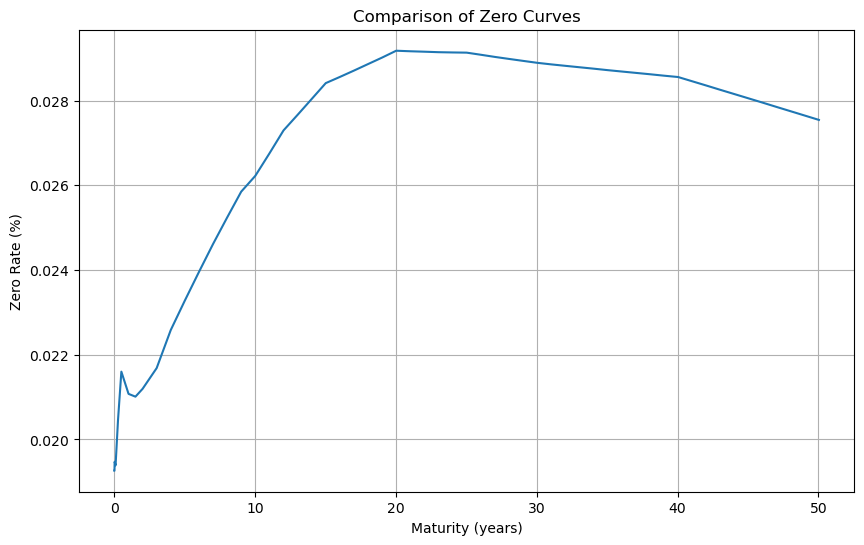

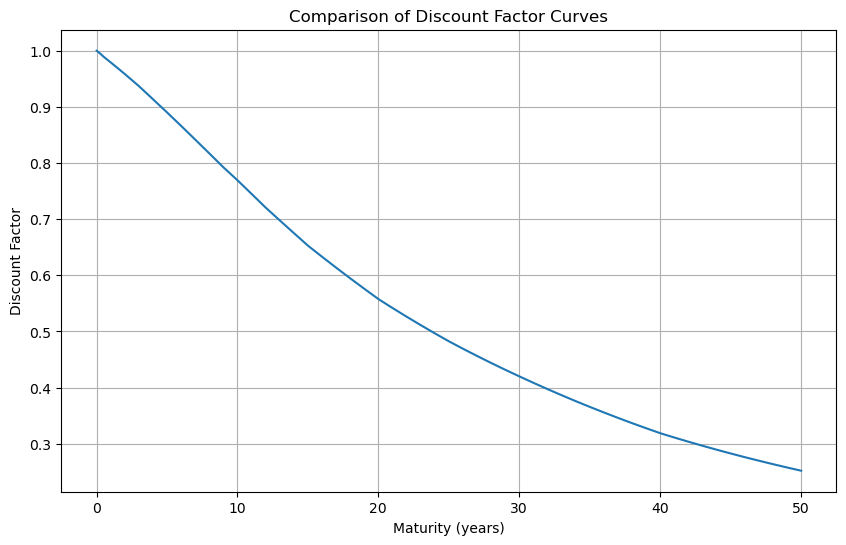

In [ ]:
import matplotlib.pyplot as plt

# Make clean copies
m1 = final_curve.copy()

# ----------------------------
# Zero curve chart
# ----------------------------
plt.figure(figsize=(10, 6))
plt.plot(m1["TTM"], m1["Zero Rate"])
plt.xlabel("Maturity (years)")
plt.ylabel("Zero Rate (%)")
plt.title("EUR IRS Zero Curve (bootstrapped, 05-Nov-2025)")
plt.grid(True)
plt.show()

# ----------------------------
# Discount factor chart
# ----------------------------
plt.figure(figsize=(10, 6))
plt.plot(m1["TTM"], m1["DF"])
plt.xlabel("Maturity (years)")
plt.ylabel("Discount Factor")
plt.title("EUR IRS Discount Factor Curve (bootstrapped, 05-Nov-2025)")
plt.grid(True)
plt.show()

In [ ]:
# Make sure final_curve is sorted by Days
fc = final_curve.copy().sort_values("Days").reset_index(drop=True)

# Extract arrays from final_curve
known_days = fc["Days"].to_numpy(dtype=float)
known_zero = fc["Zero Rate"].to_numpy(dtype=float)

# Build full day grid from 0 to last day
last_day = int(fc["Days"].max())
all_days = np.arange(0, last_day + 1, 1)

# TTM on Act/365 basis
all_ttm = all_days / 365.0

# Linear interpolation of continuously compounded zero rates
interp_zero = np.interp(all_days, known_days, known_zero)

# Discount factors from interpolated zero curve
interp_df = np.exp(-interp_zero * all_ttm)

# Create table
Interp_term_structure = pd.DataFrame({
    "Days": all_days,
    "TTM": all_ttm,
    "Zero rate (c.c.)": interp_zero,
    "DF": interp_df
})

Interp_term_structure.head()

,Days,TTM,Zero rate (c.c.),DF
0,0,0.000000,0.019262,1.000000
1,1,0.002740,0.019262,0.999947
2,2,0.005479,0.019262,0.999894
3,3,0.008219,0.019262,0.999842
4,4,0.010959,0.019315,0.999788


In [ ]:
Interp_term_structure.tail()

,Days,TTM,Zero rate (c.c.),DF
18258,18258,50.021918,0.027545,0.252123
18259,18259,50.024658,0.027544,0.252108
18260,18260,50.027397,0.027544,0.252092
18261,18261,50.030137,0.027544,0.252077
18262,18262,50.032877,0.027544,0.252061


In [ ]:
final_curve.head()

,Days,Maturity Date,TTM,Zero Rate,DF
0,0,2025-11-07,0.000000,0.019262,1.000000
1,3,2025-11-10,0.008219,0.019262,0.999842
2,7,2025-11-14,0.019178,0.019473,0.999627
3,31,2025-12-08,0.084932,0.019390,0.998355
4,94,2026-02-09,0.257534,0.020457,0.994745


In [ ]:
Interp_term_structure.to_excel("Interp_term_structure.xlsx", index=False)